# Sanity Check - Step 03: Bandpass Filter (1-40 Hz)

Überprüft:
- Filter korrekt angewendet (1-40 Hz)
- Signalverlauf nach Filterung
- Vorher/Nachher PSD Vergleich

In [1]:
import sys
import mne
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / 'eeg_pipeline'))
import config

print("Setup erfolgreich")

Setup erfolgreich


## 1. VORHER: CAR Re-referenced Raw Daten (Step 02 Output)

In [2]:
subject_id = config.SUBJECTS[0]

# Step 02 Output laden
p1_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P1_renamed_raw_CAR_raw.fif"
p2_path_before = config.OUTPUT_DIR / f"sub-{subject_id}_P2_renamed_raw_CAR_raw.fif"

raw_p1_before = mne.io.read_raw_fif(str(p1_path_before), preload=False)
raw_p2_before = mne.io.read_raw_fif(str(p2_path_before), preload=False)

print(f"\n=== VORHER (Step 02 Output - CAR) ===\n")
print(f"Person 1:")
print(f"  Sampling Rate: {raw_p1_before.info['sfreq']} Hz")
print(f"  Datenlänge: {raw_p1_before.n_times} Samples")
print(f"  Dauer: {raw_p1_before.times[-1]:.2f} Sekunden")

print(f"\nPerson 2:")
print(f"  Sampling Rate: {raw_p2_before.info['sfreq']} Hz")
print(f"  Datenlänge: {raw_p2_before.n_times} Samples")
print(f"  Dauer: {raw_p2_before.times[-1]:.2f} Sekunden")

Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw_CAR_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_renamed_raw_CAR_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== VORHER (Step 02 Output - CAR) ===

Person 1:
  Sampling Rate: 2048.0 Hz
  Datenlänge: 7514112 Samples
  Dauer: 3669.00 Sekunden

Person 2:
  Sampling Rate: 2048.0 Hz
  Datenlänge: 7514112 Samples
  Dauer: 3669.00 Sekunden


## 2. NACHHER: Gefilterte Raw Daten (Step 03 Output)

In [3]:
# Step 03 Output laden
p1_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P1_filtered.fif"
p2_path_after = config.OUTPUT_DIR / f"sub-{subject_id}_P2_filtered.fif"

raw_p1_after = mne.io.read_raw_fif(str(p1_path_after), preload=False)
raw_p2_after = mne.io.read_raw_fif(str(p2_path_after), preload=False)

print(f"\n=== NACHHER (Step 03 Output - Filtered) ===\n")
print(f"Person 1:")
print(f"  Sampling Rate: {raw_p1_after.info['sfreq']} Hz")
print(f"  Datenlänge: {raw_p1_after.n_times} Samples")
print(f"  Dauer: {raw_p1_after.times[-1]:.2f} Sekunden")

print(f"\nPerson 2:")
print(f"  Sampling Rate: {raw_p2_after.info['sfreq']} Hz")
print(f"  Datenlänge: {raw_p2_after.n_times} Samples")
print(f"  Dauer: {raw_p2_after.times[-1]:.2f} Sekunden")

Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_filtered.fif...


C:\Users\bk57s\AppData\Local\Temp\ipykernel_14976\781196760.py:5: RuntimeWarning: This filename (c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_p1_after = mne.io.read_raw_fif(str(p1_path_after), preload=False)


    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_filtered.fif...


C:\Users\bk57s\AppData\Local\Temp\ipykernel_14976\781196760.py:6: RuntimeWarning: This filename (c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P2_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_p2_after = mne.io.read_raw_fif(str(p2_path_after), preload=False)


    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.

=== NACHHER (Step 03 Output - Filtered) ===

Person 1:
  Sampling Rate: 2048.0 Hz
  Datenlänge: 7514112 Samples
  Dauer: 3669.00 Sekunden

Person 2:
  Sampling Rate: 2048.0 Hz
  Datenlänge: 7514112 Samples
  Dauer: 3669.00 Sekunden


## 3. PSD Vergleich: VORHER vs. NACHHER

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


C:\Users\bk57s\AppData\Local\Temp\ipykernel_14976\4272514750.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


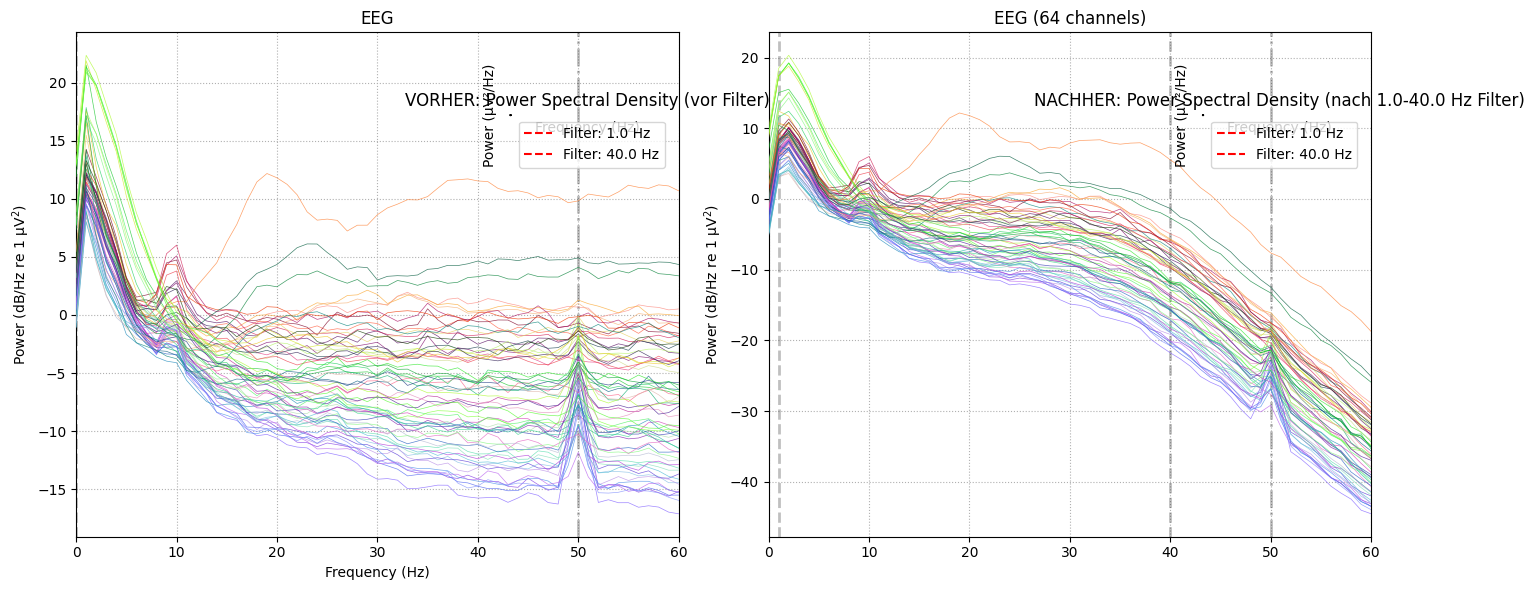

In [4]:
# PSD plotten (0-60 Hz) - use limited time window to save memory
fig = plt.figure(figsize=(14, 6))

# Use only first 300 seconds for PSD computation to save memory
tmax_psd = min(300, raw_p1_before.times[-1])

# VORHER
plt.subplot(1, 2, 1)
raw_p1_before_eeg = raw_p1_before.copy().pick_types(eeg=True)
raw_p1_before_eeg.plot_psd(fmax=60, ax=plt.gca(), show=False, color='blue', tmax=tmax_psd, method='welch')
plt.axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter: {config.FREQ_LOWER} Hz')
plt.axvline(x=config.FREQ_UPPER, color='red', linestyle='--', label=f'Filter: {config.FREQ_UPPER} Hz')
plt.title('VORHER: Power Spectral Density (vor Filter)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')
plt.legend()
plt.ylim(bottom=0)

# NACHHER
plt.subplot(1, 2, 2)
raw_p1_after_eeg = raw_p1_after.copy().pick_types(eeg=True)
raw_p1_after_eeg.plot_psd(fmax=60, ax=plt.gca(), show=False, color='green', tmax=tmax_psd, method='welch')
plt.axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter: {config.FREQ_LOWER} Hz')
plt.axvline(x=config.FREQ_UPPER, color='red', linestyle='--', label=f'Filter: {config.FREQ_UPPER} Hz')
plt.title(f'NACHHER: Power Spectral Density (nach {config.FREQ_LOWER}-{config.FREQ_UPPER} Hz Filter)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')
plt.legend()
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

## 4. Zeitbereich Vergleich: Rohdaten vs. Gefiltert

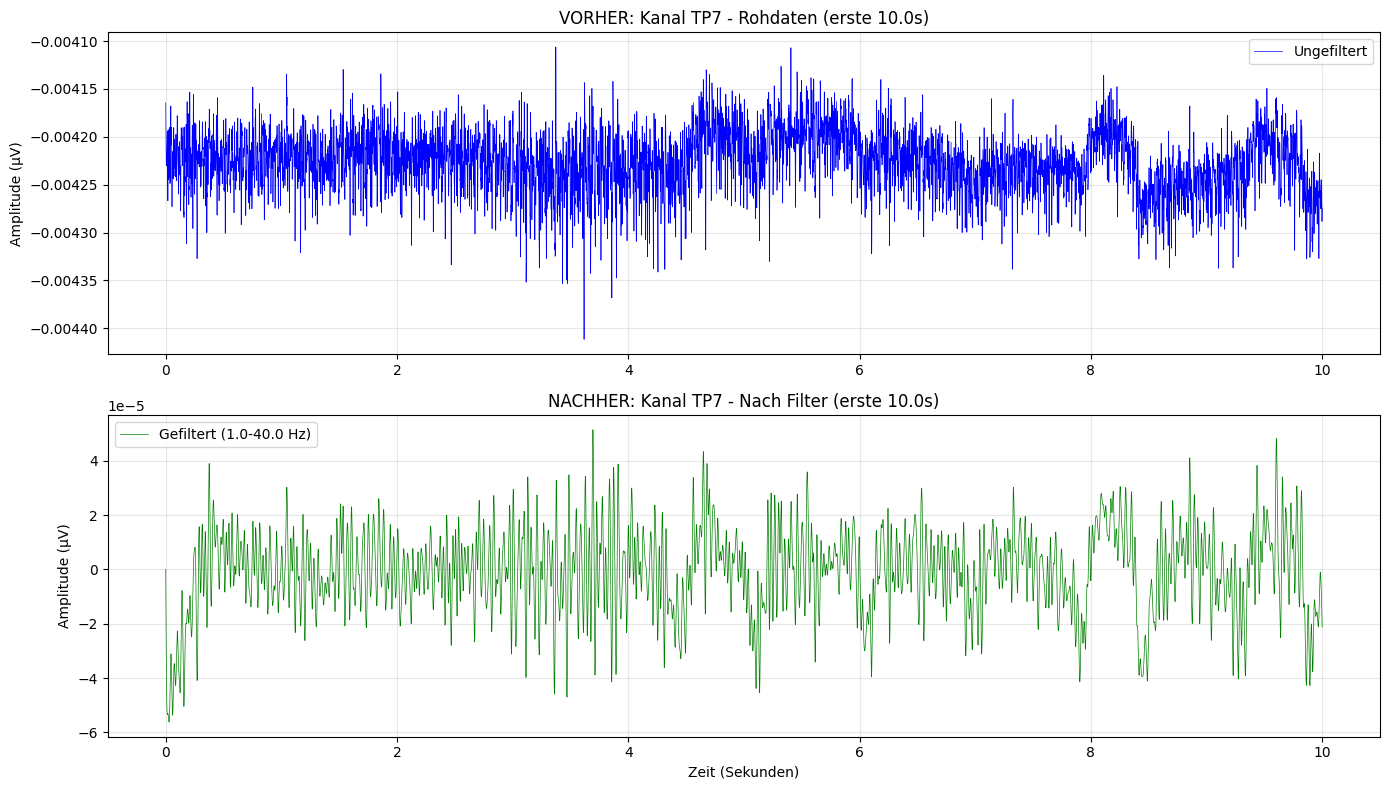

Vergleichter Kanal: TP7


In [5]:
# Vergleiche ein Kanal im Zeitbereich
eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)

# Wähle einen exemplarischen EEG Kanal
ch_idx = 15  # Mittlerer Kanal
ch_name = np.array(raw_p1_before.ch_names)[eeg_picks][ch_idx]

# Extraiere Zeitreihe (erste 10 Sekunden) - nur kleine Zeitfenster laden, nicht alles!
t_end = min(10, raw_p1_before.times[-1])
t_idx_end = int(t_end * raw_p1_before.info['sfreq'])

# Load only the small time window needed for visualization (not the full dataset)
data_before = raw_p1_before.get_data(picks=eeg_picks, start=0, stop=t_idx_end)[ch_idx, :]
data_after = raw_p1_after.get_data(picks=eeg_picks, start=0, stop=t_idx_end)[ch_idx, :]
times = raw_p1_before.times[:t_idx_end]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# VORHER
ax1 = axes[0]
ax1.plot(times, data_before, 'b-', linewidth=0.5, label='Ungefiltert')
ax1.set_ylabel('Amplitude (µV)')
ax1.set_title(f'VORHER: Kanal {ch_name} - Rohdaten (erste {t_end:.1f}s)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# NACHHER
ax2 = axes[1]
ax2.plot(times, data_after, 'g-', linewidth=0.5, label=f'Gefiltert ({config.FREQ_LOWER}-{config.FREQ_UPPER} Hz)')
ax2.set_xlabel('Zeit (Sekunden)')
ax2.set_ylabel('Amplitude (µV)')
ax2.set_title(f'NACHHER: Kanal {ch_name} - Nach Filter (erste {t_end:.1f}s)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Vergleichter Kanal: {ch_name}")

## 5. Amplituden Statistiken Vergleich

In [6]:
# Hole EEG Daten - compute statistics per-channel to avoid loading all data at once
eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)

# Compute statistics for BEFORE data (channel by channel)
data_before_stats = []
for pick_idx in eeg_picks:
    ch_data = raw_p1_before.get_data(picks=[pick_idx])
    data_before_stats.append({
        'min': np.min(ch_data),
        'max': np.max(ch_data),
        'mean': np.mean(ch_data),
        'std': np.std(ch_data),
        'p2p': np.max(ch_data) - np.min(ch_data)
    })

# Compute statistics for AFTER data (channel by channel)
data_after_stats = []
for pick_idx in eeg_picks:
    ch_data = raw_p1_after.get_data(picks=[pick_idx])
    data_after_stats.append({
        'min': np.min(ch_data),
        'max': np.max(ch_data),
        'mean': np.mean(ch_data),
        'std': np.std(ch_data),
        'p2p': np.max(ch_data) - np.min(ch_data)
    })

# Average the statistics across channels
min_before = np.mean([s['min'] for s in data_before_stats])
max_before = np.mean([s['max'] for s in data_before_stats])
mean_before = np.mean([s['mean'] for s in data_before_stats])
std_before = np.mean([s['std'] for s in data_before_stats])
p2p_before = np.mean([s['p2p'] for s in data_before_stats])

min_after = np.mean([s['min'] for s in data_after_stats])
max_after = np.mean([s['max'] for s in data_after_stats])
mean_after = np.mean([s['mean'] for s in data_after_stats])
std_after = np.mean([s['std'] for s in data_after_stats])
p2p_after = np.mean([s['p2p'] for s in data_after_stats])

print(f"\n=== AMPLITUDEN STATISTIKEN (Person 1) ===\n")

print(f"VORHER (ungefiltert):")
print(f"  Min: {min_before:.6f} µV")
print(f"  Max: {max_before:.6f} µV")
print(f"  Mean: {mean_before:.6f} µV")
print(f"  Std: {std_before:.6f} µV")
print(f"  Peak-to-Peak: {p2p_before:.6f} µV")

print(f"\nNACHHER (gefiltert {config.FREQ_LOWER}-{config.FREQ_UPPER} Hz):")
print(f"  Min: {min_after:.6f} µV")
print(f"  Max: {max_after:.6f} µV")
print(f"  Mean: {mean_after:.6f} µV")
print(f"  Std: {std_after:.6f} µV")
print(f"  Peak-to-Peak: {p2p_after:.6f} µV")

print(f"\nÄNDERUNG:")
print(f"  Amplitude-Reduktion (Std): {(1 - std_after/std_before)*100:.2f}%")
print(f"  Peak-to-Peak-Reduktion: {(1 - p2p_after/p2p_before)*100:.2f}%")


=== AMPLITUDEN STATISTIKEN (Person 1) ===

VORHER (ungefiltert):
  Min: -0.001109 µV
  Max: 0.001112 µV
  Mean: -0.000000 µV
  Std: 0.000541 µV
  Peak-to-Peak: 0.002221 µV

NACHHER (gefiltert 1.0-40.0 Hz):
  Min: -0.000095 µV
  Max: 0.000102 µV
  Mean: 0.000000 µV
  Std: 0.000007 µV
  Peak-to-Peak: 0.000197 µV

ÄNDERUNG:
  Amplitude-Reduktion (Std): 98.71%
  Peak-to-Peak-Reduktion: 91.13%


## 6. Frequenzbereich Analyse: Bandpass Check

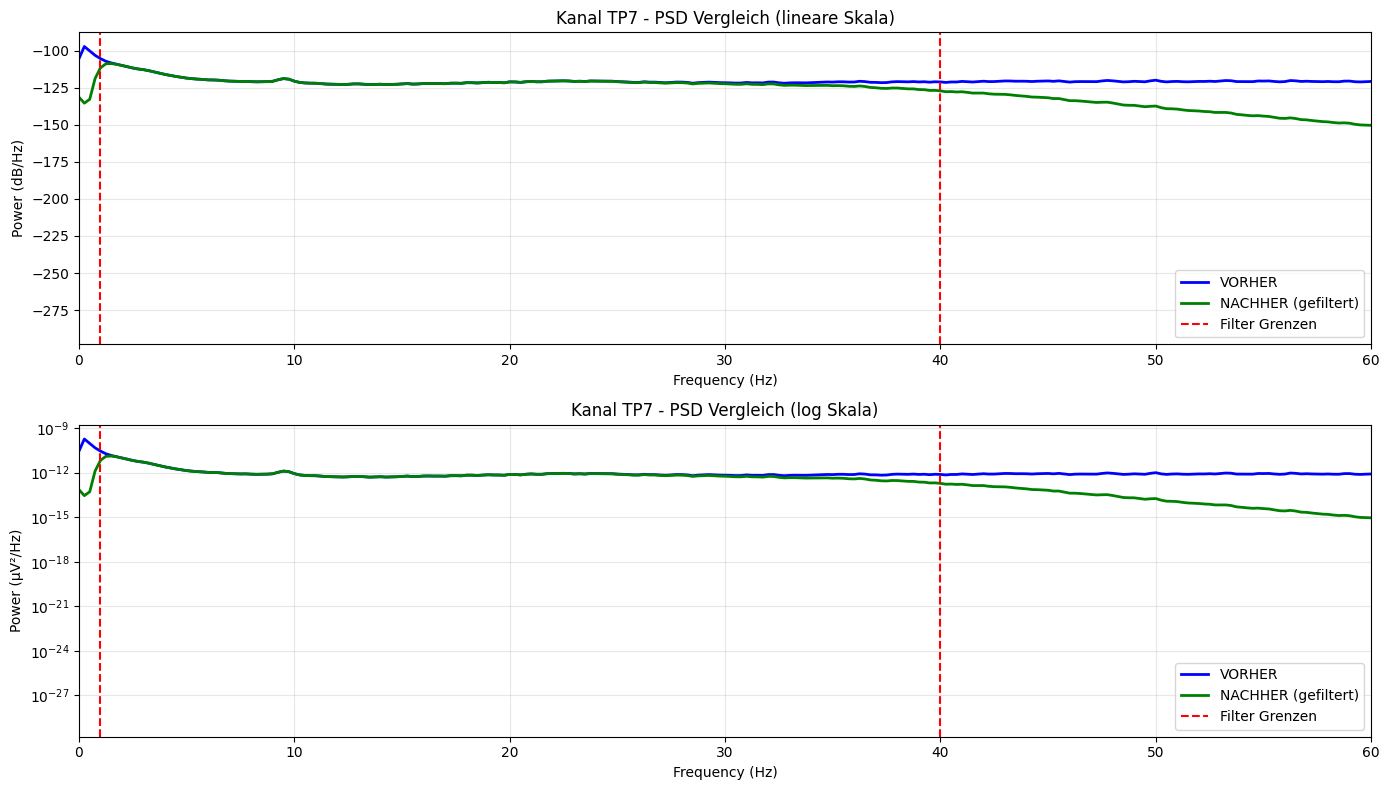

In [8]:
from scipy import signal

# Berechne Frequenzspektrum für ein Sample - load only one channel to avoid memory issues
eeg_picks = mne.pick_types(raw_p1_before.info, eeg=True)

# Load only the specific channel we need (ch_idx)
target_pick = eeg_picks[ch_idx]
data_before_ch = raw_p1_before.get_data(picks=[target_pick]).squeeze()
data_after_ch = raw_p1_after.get_data(picks=[target_pick]).squeeze()

fs = raw_p1_before.info['sfreq']

# Welch's method für PSD
freqs_before, psd_before = signal.welch(data_before_ch, fs, nperseg=fs*4)
freqs_after, psd_after = signal.welch(data_after_ch, fs, nperseg=fs*4)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Lineare Skala
ax1 = axes[0]
ax1.plot(freqs_before, 10*np.log10(psd_before), 'b-', label='VORHER', linewidth=2)
ax1.plot(freqs_after, 10*np.log10(psd_after), 'g-', label='NACHHER (gefiltert)', linewidth=2)
ax1.axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter Grenzen')
ax1.axvline(x=config.FREQ_UPPER, color='red', linestyle='--')
ax1.set_xlim([0, 60])
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Power (dB/Hz)')
ax1.set_title(f'Kanal {ch_name} - PSD Vergleich (lineare Skala)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Log Skala für Details
ax2 = axes[1]
ax2.semilogy(freqs_before, psd_before, 'b-', label='VORHER', linewidth=2)
ax2.semilogy(freqs_after, psd_after, 'g-', label='NACHHER (gefiltert)', linewidth=2)
ax2.axvline(x=config.FREQ_LOWER, color='red', linestyle='--', label=f'Filter Grenzen')
ax2.axvline(x=config.FREQ_UPPER, color='red', linestyle='--')
ax2.set_xlim([0, 60])
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (µV²/Hz)')
ax2.set_title(f'Kanal {ch_name} - PSD Vergleich (log Skala)')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Zusammenfassung & Validierung

In [9]:
print(f"\n=== SANITY CHECK ZUSAMMENFASSUNG ===\n")

checks = []

# 1. Daten-Shape sollte gleich sein (Filter ändert nicht die Länge)
same_shape = data_before.shape == data_after.shape
checks.append(("Daten-Shape gleich", same_shape))

# 2. Sampling Rate sollte gleich sein
same_sfreq = raw_p1_before.info['sfreq'] == raw_p1_after.info['sfreq']
checks.append(("Sampling Rate gleich", same_sfreq))

# 3. Kanal-Namen sollten gleich sein
same_channels = raw_p1_before.ch_names == raw_p1_after.ch_names
checks.append(("Kanal-Namen gleich", same_channels))

# 4. Amplitude sollte reduziert sein (Filter reduziert hohe Frequenzen)
amp_reduced = np.std(data_after) < np.std(data_before)
checks.append(("Amplitude reduziert durch Filter", amp_reduced))

# 5. Power außerhalb des Passbands sollte stark reduziert sein
# Prüfe Power < 1 Hz und > 40 Hz
freq_mask_low = freqs_before < 1
freq_mask_high = freqs_before > 40
power_low_before = np.mean(psd_before[freq_mask_low])
power_low_after = np.mean(psd_after[freq_mask_low])
power_high_before = np.mean(psd_before[freq_mask_high])
power_high_after = np.mean(psd_after[freq_mask_high])

# Die gefilterte Version sollte weniger Power außerhalb haben
low_freq_reduced = power_low_after < power_low_before
high_freq_reduced = power_high_after < power_high_before
checks.append(("Niederfrequenz Power reduziert (<1 Hz)", low_freq_reduced))
checks.append(("Hochfrequenz Power reduziert (>40 Hz)", high_freq_reduced))

# 6. Keine NaN oder Inf
no_nan_inf = not (np.isnan(data_after).any() or np.isinf(data_after).any())
checks.append(("Keine NaN/Inf Werte", no_nan_inf))

# 7. Zeitdauer sollte gleich sein
same_duration = abs(raw_p1_before.times[-1] - raw_p1_after.times[-1]) < 0.01
checks.append(("Zeitdauer gleich", same_duration))

for check_name, result in checks:
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"{status}: {check_name}")

all_pass = all(result for _, result in checks)
print(f"\n{'='*50}")
if all_pass:
    print("✓ ALLE CHECKS BESTANDEN")
else:
    print("✗ EINIGE CHECKS FEHLGESCHLAGEN")
print(f"{'='*50}")


=== SANITY CHECK ZUSAMMENFASSUNG ===

✓ PASS: Daten-Shape gleich
✓ PASS: Sampling Rate gleich
✓ PASS: Kanal-Namen gleich
✓ PASS: Amplitude reduziert durch Filter
✓ PASS: Niederfrequenz Power reduziert (<1 Hz)
✓ PASS: Hochfrequenz Power reduziert (>40 Hz)
✓ PASS: Keine NaN/Inf Werte
✓ PASS: Zeitdauer gleich

✓ ALLE CHECKS BESTANDEN
